# Importación de librerías datos y funciones

In [41]:
# importación de librerías
import warnings
warnings.filterwarnings("ignore")
import sys
import os
# Le dice python que busque liberrías ahí también
sys.path.append(os.path.join('src'))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, make_scorer
import funciones_personales as fp

In [2]:
gr_train = pd.read_csv('datasets/gold_recovery_train.csv')
gr_test = pd.read_csv('datasets/gold_recovery_test.csv')
gr_full = pd.read_csv('datasets/gold_recovery_full.csv')


## 1.1 Aanálisis inicial de datos

In [3]:
print(gr_full.info())
print('*'*50)
print(gr_full.shape)
nan_full = fp.mostrar_nan(gr_full, mostrar=True, num_filas=0)
dupli_full = fp.mostrar_dupli(gr_full, columna=None, num_filas=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


In [4]:
print(gr_train.info())
print('*'*50)
print(gr_train.shape)
nan_train = fp.mostrar_nan(gr_train, mostrar=True, num_filas=0)
dupli_train = fp.mostrar_dupli(gr_train, columna=None, num_filas=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64



Total de filas con NaN: 5843

Cantidad de NaN por columna:
  date: 0
  final.output.concentrate_ag: 72
  final.output.concentrate_pb: 72
  final.output.concentrate_sol: 370
  final.output.concentrate_au: 71
  final.output.recovery: 1521
  final.output.tail_ag: 66
  final.output.tail_pb: 183
  final.output.tail_sol: 145
  final.output.tail_au: 66
  primary_cleaner.input.sulfate: 1307
  primary_cleaner.input.depressant: 1262
  primary_cleaner.input.feed_size: 0
  primary_cleaner.input.xanthate: 985
  primary_cleaner.output.concentrate_ag: 82
  primary_cleaner.output.concentrate_pb: 358
  primary_cleaner.output.concentrate_sol: 636
  primary_cleaner.output.concentrate_au: 82
  primary_cleaner.output.tail_ag: 83
  primary_cleaner.output.tail_pb: 99
  primary_cleaner.output.tail_sol: 281
  primary_cleaner.output.tail_au: 83
  primary_cleaner.state.floatbank8_a_air: 40
  primary_cleaner.state.floatbank8_a_level: 33
  primary_cleaner.state.floatbank8_b_air: 40
  primary_cleaner.state.floatba

In [5]:
print(gr_test.info())
print('*'*50)
print(gr_test.shape)
nan_test = fp.mostrar_nan(gr_test, mostrar=True, num_filas=0)
dupli_test = fp.mostrar_dupli(gr_test, columna=None, num_filas=0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea


Total de filas con NaN: 473

Cantidad de NaN por columna:
  date: 0
  primary_cleaner.input.sulfate: 302
  primary_cleaner.input.depressant: 284
  primary_cleaner.input.feed_size: 0
  primary_cleaner.input.xanthate: 166
  primary_cleaner.state.floatbank8_a_air: 16
  primary_cleaner.state.floatbank8_a_level: 16
  primary_cleaner.state.floatbank8_b_air: 16
  primary_cleaner.state.floatbank8_b_level: 16
  primary_cleaner.state.floatbank8_c_air: 16
  primary_cleaner.state.floatbank8_c_level: 16
  primary_cleaner.state.floatbank8_d_air: 16
  primary_cleaner.state.floatbank8_d_level: 16
  rougher.input.feed_ag: 16
  rougher.input.feed_pb: 16
  rougher.input.feed_rate: 40
  rougher.input.feed_size: 22
  rougher.input.feed_sol: 67
  rougher.input.feed_au: 16
  rougher.input.floatbank10_sulfate: 257
  rougher.input.floatbank10_xanthate: 123
  rougher.input.floatbank11_sulfate: 55
  rougher.input.floatbank11_xanthate: 353
  rougher.state.floatbank10_a_air: 17
  rougher.state.floatbank10_a_level

### Hallazgos
* Tenemos 5,843 filas con vaalores Nan en train de un total de 16,860 filas, esto representa el 34% de los datos
* Dado que los datos son secuenciales en el tiempo, se recomienda usar el valor inmediato anterior del valor faltante en lugar de la media del total de datos de la columna.
* La columna date esta en formato object por lo que se recomienta cambiarlo por formato datetime

## 1.2 Cálculo y verificación para de recovery para datos crudos:
    

In [6]:
# Se nombran las variables a usar para la ecuación de recovery para rougher y final:
c_r= gr_train['rougher.output.concentrate_au']
c_f= gr_train['final.output.concentrate_au']
f_r= gr_train['rougher.input.feed_au']
f_f= gr_train['rougher.input.feed_au']
t_r= gr_train['rougher.output.tail_au']
t_f= gr_train['final.output.tail_au']
# Se aplica la ecuación brindada por el ejercicio para el cálculo de recuperación:
recovery_r_manual=((c_r*(f_r-t_r))/(f_r*(c_r-t_r)))*100
recovery_f_manual=((c_f*(f_f-t_f))/(f_f*(c_f-t_f)))*100

In [7]:
# se investigan la cantidad de valores NaN entre el cálculo manual y el del sistema
nan_recovery_r_manual= fp.mostrar_nan(pd.DataFrame(recovery_r_manual), mostrar=True, num_filas=0)
nan_recovery_r_system= fp.mostrar_nan(gr_train, columna='rougher.output.recovery', mostrar=True, num_filas=0)
nan_recovery_f_manual= fp.mostrar_nan(pd.DataFrame(recovery_f_manual), mostrar=True, num_filas=0)
nan_recovery_f_system= fp.mostrar_nan(gr_train, columna='final.output.recovery', mostrar=True, num_filas=0)


Total de filas con NaN: 2283

Cantidad de NaN por columna:
  0: 2283

Primeras 0 filas con NaN:
Empty DataFrame
Columns: [0]
Index: []
--------------------------------------------------

Filas con NaN en 'rougher.output.recovery': 2573 encontradas

Primeras 0 filas completas conteniendo NaN para:  ' rougher.output.recovery '
Empty DataFrame
Columns: [date, final.output.concentrate_ag, final.output.concentrate_pb, final.output.concentrate_sol, final.output.concentrate_au, final.output.recovery, final.output.tail_ag, final.output.tail_pb, final.output.tail_sol, final.output.tail_au, primary_cleaner.input.sulfate, primary_cleaner.input.depressant, primary_cleaner.input.feed_size, primary_cleaner.input.xanthate, primary_cleaner.output.concentrate_ag, primary_cleaner.output.concentrate_pb, primary_cleaner.output.concentrate_sol, primary_cleaner.output.concentrate_au, primary_cleaner.output.tail_ag, primary_cleaner.output.tail_pb, primary_cleaner.output.tail_sol, primary_cleaner.output.tail

### Hallazgos
**Comparación de valores NAN arrojados por el cálculo manual vs el original para rougher:**
* Manual: 2283 
* Original: 2573
* Diferencia: 290

**Comparación de valores NAN arrojados por el cálculo manual vs el original para final:**
* Manual: 1278
* Original: 1521
* Diferencia: 243

**hipótesis**

Lo mas probable es que el cálculo que realiza el sistema tome en cuenta más parámetros que la ecuación utilizada para el cálculo manual 

**Siguientes pasos**

Se creará un df con las columnas del cálculo manual y el sistema emparejadas 1 a 1 y se aplicará dropna para tener únicamente valores válidos para MAE y con el mismo número de valores para cada columna

In [8]:
## se crean los dataframes para rougher y final:
#concatena columnas completas
df_r_para_mae= pd.concat([recovery_r_manual, gr_train['rougher.output.recovery']], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
df_f_para_mae= pd.concat([recovery_f_manual, gr_train['final.output.recovery']], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
# calcula MAE para rougher y final
mae_r = mean_absolute_error(df_r_para_mae[0], df_r_para_mae['rougher.output.recovery'])
mae_f = mean_absolute_error(df_f_para_mae[0], df_f_para_mae['final.output.recovery'])

In [9]:
print(f"el Error Medio Absoluto para rougher y final es {mae_r} y {mae_f} respectivamente")

el Error Medio Absoluto para rougher y final es 9.303415616264301e-15 y 7.974449743579576e-15 respectivamente


### Hallazgos

Los valores del MAE tan cercanos a cero nos indican que el cálculo manual vs el cálculo del sistema son homólogos

## 1.3 Análisis de las carácteristicas no disponibles en el conjunto de prueba

In [10]:
cols_test= set(gr_test.columns)
cols_train= set(gr_train.columns)
solo_train= cols_train - cols_test
print(f"Columnas presentes sólo en train: {solo_train} ")

Columnas presentes sólo en train: {'rougher.calculation.au_pb_ratio', 'rougher.output.tail_ag', 'primary_cleaner.output.tail_au', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'primary_cleaner.output.tail_pb', 'secondary_cleaner.output.tail_sol', 'primary_cleaner.output.tail_ag', 'final.output.concentrate_pb', 'rougher.output.concentrate_pb', 'rougher.output.concentrate_ag', 'primary_cleaner.output.concentrate_sol', 'primary_cleaner.output.concentrate_au', 'secondary_cleaner.output.tail_au', 'final.output.tail_pb', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'primary_cleaner.output.concentrate_ag', 'primary_cleaner.output.tail_sol', 'primary_cleaner.output.concentrate_pb', 'final.output.recovery', 'secondary_cleaner.output.tail_ag', 'final.output.concentrate_au', 'rougher.calculation.sulfate_to_au_concentrate', 'rougher.output.recovery', 'rougher.output.tail_au', 'rougher.output.concentrate_sol', 'final.output.concentrate_ag', 'final.output.tail_au', 'final.output.con

### Hallazgos

Existen 34 columnas que están en el train pero no en el test:

* 4 de estos son calculos internos en rougher (rougher.calculation.*)
    * rougher.calculation.au_pb_ratio
    * rougher.calculation.floatbank11_sulfate_to_au_feed
    * rougher.calculation.floatbank10_sulfate_to_au_feed
    * rougher.calculation.sulfate_to_au_concentrate
* 30 corresponden al parámetro output (\*.output.\*)
    * 9 de rougher.output.*:
        * rougher.output.concentrate_pb
        * rougher.output.concentrate_au
        * rougher.output.concentrate_sol
        * rougher.output.concentrate_ag
        * rougher.output.tail_pb
        * rougher.output.tail_au
        * rougher.output.tail_sol
        * rougher.output.tail_ag
        * rougher.output.recovery
    * 8 de primary_cleaner.output.*:
        * primary_cleaner.output.concentrate_au
        * primary_cleaner.output.concentrate_sol
        * primary_cleaner.output.concentrate_ag
        * primary_cleaner.output.concentrate_pb
        * primary_cleaner.output.tail_sol
        * primary_cleaner.output.tail_pb
        * primary_cleaner.output.tail_ag
        * primary_cleaner.output.tail_au
    * 4 de secondary_cleaner.output.*:
        * secondary_cleaner.output.tail_au
        * secondary_cleaner.output.tail_sol
        * secondary_cleaner.output.tail_ag
        * secondary_cleaner.output.tail_pb
    * 9 de final.output.*:
        * final.output.concentrate_ag
        * final.output.concentrate_pb
        * final.output.concentrate_sol
        * final.output.concentrate_au
        * final.output.tail_au
        * final.output.tail_ag
        * final.output.tail_pb
        * final.output.tail_sol
        * final.output.recovery

**Conclusiones**
* Las columnas *rogher.output.recovery* y *final.output.recovery* son los target, por ello están ausentes en el test.
* Los cálculos internos y salidas de los elementos (Au, Ag, Pb, sol) tanto para los concentrados como para las colas son parámetros "*online*"
* Todos son desconocidos hasta que el proceso se realiza en tiempo real; debido a ello no se encuentran en las columnas de prueba (test)

**Siguientes pasos**
* Cuando se requiera entrenal al modelo, se deben eliminar las columnas correspondientes a parámetros online.
* Para tratar los valores ausentes se utilizará el método de rellenar con el inmediato anterior ya que se trata de un proceso continuo
* Se cambiaran los formatos de fecha a datetime truncados hasta horas ya que para minutos y segundos siempre son 0
* se verificará que df_train y df_test tengan las mismas columnas a excepción de test que cuanta con los targets (2)


## 1.4 Preprocesamiento de datos

In [11]:
## Se crea la lista de los nombres de columnas a dropear de train
lista_drop= solo_train - {'rougher.output.recovery', 'final.output.recovery'}
# Se preprocesan los datos rellenando NaN y dando formato a la fecha en ambos datasets crudos
df_train_analisis = fp.afina_datos(gr_train)
df_test = fp.afina_datos(gr_test)
# se dropean las columnas de parámetros online de train_analisis para el entrenamiento
df_train= df_train_analisis.drop(columns=lista_drop)

In [12]:
# Se comprueba que no existan valores nan en los df preprocesados
nan_train= fp.mostrar_nan(df_train, mostrar=True, num_filas=0)
nan_test = fp.mostrar_nan(df_test, mostrar=True, num_filas=0)
nan_train_analisis = fp.mostrar_nan(df_train_analisis, mostrar=True, num_filas=0)


Total de filas con NaN: 0

Cantidad de NaN por columna:
  date: 0
  final.output.recovery: 0
  primary_cleaner.input.sulfate: 0
  primary_cleaner.input.depressant: 0
  primary_cleaner.input.feed_size: 0
  primary_cleaner.input.xanthate: 0
  primary_cleaner.state.floatbank8_a_air: 0
  primary_cleaner.state.floatbank8_a_level: 0
  primary_cleaner.state.floatbank8_b_air: 0
  primary_cleaner.state.floatbank8_b_level: 0
  primary_cleaner.state.floatbank8_c_air: 0
  primary_cleaner.state.floatbank8_c_level: 0
  primary_cleaner.state.floatbank8_d_air: 0
  primary_cleaner.state.floatbank8_d_level: 0
  rougher.input.feed_ag: 0
  rougher.input.feed_pb: 0
  rougher.input.feed_rate: 0
  rougher.input.feed_size: 0
  rougher.input.feed_sol: 0
  rougher.input.feed_au: 0
  rougher.input.floatbank10_sulfate: 0
  rougher.input.floatbank10_xanthate: 0
  rougher.input.floatbank11_sulfate: 0
  rougher.input.floatbank11_xanthate: 0
  rougher.output.recovery: 0
  rougher.state.floatbank10_a_air: 0
  rougher

In [13]:
# se verifica que los nombres de columnas sean los mismos en ambos datasets preprocesados
cols_test= set(df_test.columns)
cols_train= set(df_train.columns)
solo_train= cols_train - cols_test
solo_test= cols_test - cols_train
print(f"Columnas presentes sólo en train: {solo_train} ")
print(f"Columnas presentes sólo en test: {solo_test} ")


Columnas presentes sólo en train: {'rougher.output.recovery', 'final.output.recovery'} 
Columnas presentes sólo en test: set() 


### Conclusión
* Se han creado los df para el modelo (df_test y df_train)
* Se crea un df para el análisis del paso posterios (df_train_analisis)

# 2 Análisis de datos

## 2.1 Cambio de la concentración de Au, Ag y Pb en función de etapas de purificación 

El proceso de purificación tiene 3 etapas donde se miden las concentraciones de Au, Ag y Pb:
* Alimentación o feed (input):
    * `rougher.input.feed_au`
    * `rougher.input.feed_ag`
    * `rougher.input.feed_pb`
* Concentrado rougher:
    * `rougher.output.concentrate_au`
    * `rougher.output.concentrate_ag`
    * `rougher.output.concentrate_pb`
* Concentrado final:
    * `final.output.concentrate_au`
    * `final.output.concentrate_ag`
    * `final.output.concentrate_pb`

Se realizará un gráfico de barras con las etapas en el eje *x* y los promedios de concentraciones de los elementos en el eje *y*

In [14]:
## Se obtienen las medias de las columnas a graficar:
# Para rougher.input.feed:
rou_inp_feed_au_mean= df_train_analisis['rougher.input.feed_au'].mean()
rou_inp_feed_ag_mean= df_train_analisis['rougher.input.feed_ag'].mean()
rou_inp_feed_pb_mean= df_train_analisis['rougher.input.feed_pb'].mean()
# Para rougher.output.concentrate:
rou_out_conc_au_mean= df_train_analisis['rougher.output.concentrate_au'].mean()
rou_out_conc_ag_mean= df_train_analisis['rougher.output.concentrate_ag'].mean()
rou_out_conc_pb_mean= df_train_analisis['rougher.output.concentrate_pb'].mean()
# Para final.output.concentrate:
fin_out_conc_au_mean= df_train_analisis['final.output.concentrate_au'].mean()
fin_out_conc_ag_mean= df_train_analisis['final.output.concentrate_ag'].mean()
fin_out_conc_pb_mean= df_train_analisis['final.output.concentrate_pb'].mean()

## Se crean los objetos a utilizarse en el gráfico:
# Se crea un diccionario con claves Au, Ag y Pb cuyos valores son listas con las medias de cada elemento por etapa:
datos = {
    'Au': [rou_inp_feed_au_mean, rou_out_conc_au_mean, fin_out_conc_au_mean],
    'Ag': [rou_inp_feed_ag_mean, rou_out_conc_ag_mean, fin_out_conc_ag_mean],
    'Pb': [rou_inp_feed_pb_mean, rou_out_conc_pb_mean, fin_out_conc_pb_mean]
    }
# Se crea la lista de nombres para el eje x:
etapas = ['Feed', 'Rougher', 'Final']


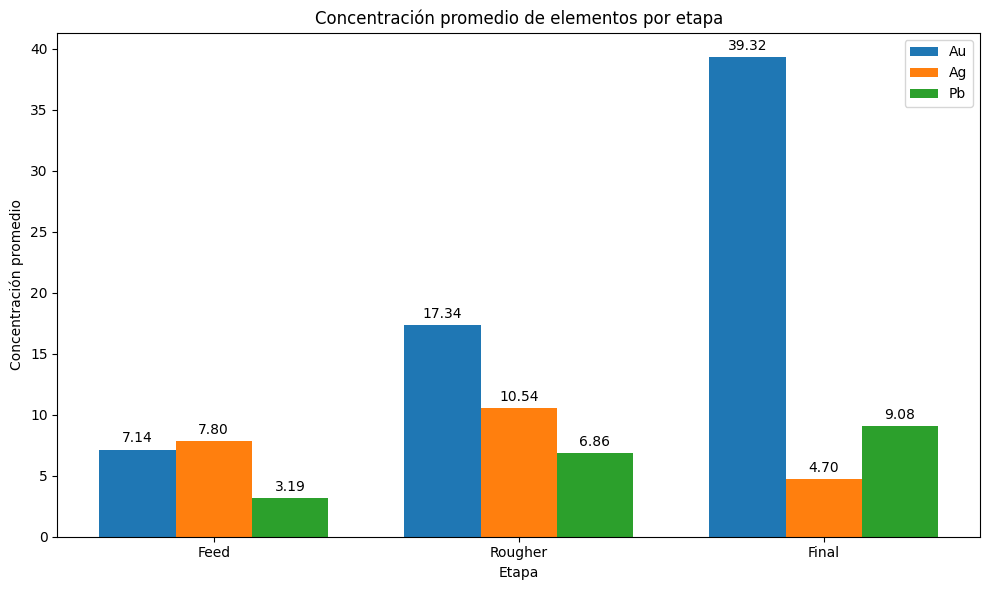

In [15]:
## Gráfico de barras:
# Posiciones de las etapas
x = np.arange(len(etapas))

# Ancho de cada barra
ancho = 0.25

# Crear figura
fig, ax = plt.subplots(figsize=(10,6))

# Crear barras para cada elemento
barras_au = ax.bar(x - ancho, datos['Au'], ancho, label='Au')
barras_ag = ax.bar(x, datos['Ag'], ancho, label='Ag')
barras_pb = ax.bar(x + ancho, datos['Pb'], ancho, label='Pb')

# Agregar valores encima de cada barra
ax.bar_label(barras_au, fmt='%.2f', padding=3)
ax.bar_label(barras_ag, fmt='%.2f', padding=3)
ax.bar_label(barras_pb, fmt='%.2f', padding=3)

# Configuración del gráfico
ax.set_title('Concentración promedio de elementos por etapa')
ax.set_xlabel('Etapa')
ax.set_ylabel('Concentración promedio')

ax.set_xticks(x)
ax.set_xticklabels(etapas)

ax.legend()

# Ajustar espacio para que no se corten las etiquetas
plt.tight_layout()

plt.show()

### Hallazgos
| Elemento | Feed | Rougher | Final |
|----------|------|---------|-------|
| Au | 7.14 | 17.34 | 39.32 |
| Ag | 7.80 | 10.54 | 4.70 |
| Pb | 3.19 | 6.86 | 9.08 |

* La concentración de oro aumenta con cada etapa (lo que es de esperarse)
* La mayor concentración de plata se obtiene al salir de flotación
* La concentración de plomo aumenta con cada etapa

**¿Por qué la plata tiene su máximo en Rougher?**

Este comportamiento es muy interesante porque indica que la plata sí fue recuperada inicialmente, pero después fue parcialmente eliminada durante la purificación.
La explicación más probable es:
* La plata está asociada a minerales que flotan muy bien en la primera etapa
* En muchos yacimientos de oro-plata, la plata aparece asociada con:
    * galena (PbS)
    * argentita (Ag₂S)
    * tetraedrita
    * electrum (Au-Ag)
La plata suele seguir al mineral portador, especialmente sulfuros de plomo.

Durante la flotación Rougher:
* entran rápidamente partículas de sulfuros
* sube la recuperación de Ag
* aumenta su concentración

Por eso:

7.8→10.54

La etapa Rougher genera un concentrado "rico", pero todavía poco selectivo.

**¿Por qué baja la plata al producto final?**

Después vienen etapas de limpieza/purificación.
Estas etapas buscan:
* aumentar Au
* reducir minerales acompañantes
* mejorar la calidad del concentrado

Si la plata está principalmente asociada con minerales de plomo, parte de esa plata puede:
* quedarse en otra corriente
* separarse con otro concentrado
* eliminarse junto con minerales considerados impurezas

Esto no significa necesariamente que se perdió toda la plata; puede significar que el circuito fue diseñado para priorizar un concentrado con mayor contenido de oro.

**¿Por qué el plomo aumenta continuamente?**
Este comportamiento indica que el plomo está siendo co-concentrado con el oro.

El plomo normalmente aparece como:
* Galena=PbS
La galena es un mineral sulfurado muy flotable, por eso suele acompañar a metales preciosos. Además, muchos depósitos de oro-plata son sistemas polimetálicos donde Au y Ag están asociados a minerales de Pb.

Durante flotación:
* la galena se vuelve hidrofóbica mediante colectores
* se adhiere a burbujas
* sube con el concentrado

Entonces cada etapa concentra más Pb

Esto sugiere que el plomo está actuando como mineral acompañante del oro.

Referencias:
https://www.911metallurgist.com/blog/silver-gold-recovery-flotation-process/

## 2.2 Comparación de distribuciones de tamaños de partículas en el feed entre train y test
* Se realizará un histograma de frecuencias y curva KDE solapados para cada dataframe utilizando los valores de la columna `rougher.input.feed_size`

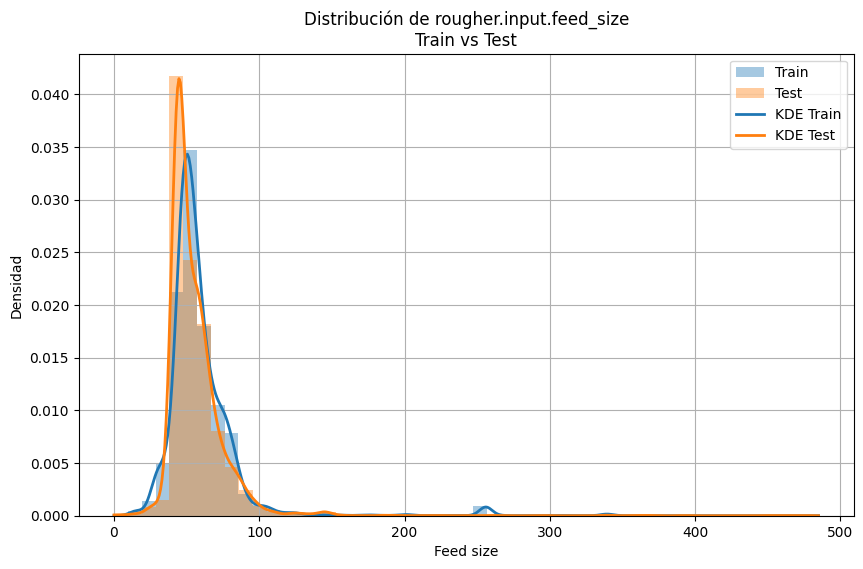

In [16]:
## Histograma y curvas normalizadas
# Seleccionar columnas
train_feed_size = df_train['rougher.input.feed_size']
test_feed_size = df_test['rougher.input.feed_size']
# Definir colores para cada conjunto
color_train = 'tab:blue'
color_test = 'tab:orange'
# Crear figura
plt.figure(figsize=(10, 6))
# Histograma normalizado
plt.hist(
    train_feed_size,
    bins=50,
    density=True,
    alpha=0.4,
    color=color_train,
    label='Train'
)
plt.hist(
    test_feed_size,
    bins=50,
    density=True,
    alpha=0.4,
    color=color_test,
    label='Test'
)
# Crear rango para KDE
x_min = min(train_feed_size.min(), test_feed_size.min())
x_max = max(train_feed_size.max(), test_feed_size.max())
x = np.linspace(x_min, x_max, 500)
# KDE
kde_train = gaussian_kde(train_feed_size)
kde_test = gaussian_kde(test_feed_size)
# Graficar curvas KDE
plt.plot(
    x,
    kde_train(x),
    linewidth=2,
    color=color_train,
    label='KDE Train'
)
plt.plot(
    x,
    kde_test(x),
    linewidth=2,
    color=color_test,
    label='KDE Test'
)
# Configuración
plt.title('Distribución de rougher.input.feed_size\nTrain vs Test')
plt.xlabel('Feed size')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

### Hallazgos
* El conjunto test tiene un valor de densidad máximo aproximado de ~ 0.043 contra ~ 0.038 con tamaños aproximados de ~ 48 y ~ 50 aproximadamente
* Se aprecia un muy pequeño pico en el conjunto train para tamaños de ~ 250 con una densidad ~ 0.001; al parecer es un dato que, por su orden de magnitud puede pasarse por alto

**Pasos siguientes**
Para tener un mejor análisis, más allá de lo visual, se deben realizar comparaciones de datos duros.

In [17]:
# comparación de descripción estadística entre train y test
print(df_train['rougher.input.feed_size'].describe())
print('='*25)
print(df_test['rougher.input.feed_size'].describe())
# número de valores mayores a 200 para train y para test
print('='*25)
total_may_200_train= df_train[df_train['rougher.input.feed_size'] > 200]['rougher.input.feed_size'].count()
total_may_200_test= df_test[df_test['rougher.input.feed_size'] > 200]['rougher.input.feed_size'].count()
# Porcentaje de valores 0 del total de datos
porc_may_200_train= (df_train['rougher.input.feed_size'] > 200).mean()*100
porc_may_200_test= (df_test['rougher.input.feed_size'] > 200).mean()*100
print(f"El totál de valores anómalos mayores a 200 para train es: {total_may_200_train}, de un total de {len(df_train['rougher.input.feed_size'])} ({porc_may_200_train:.2f}% del total para train)")
print(f"El totál de valores anómalos mayores a 200 para test es: {total_may_200_test}, de un total de {len(df_test['rougher.input.feed_size'])} ({porc_may_200_test:.2f}% del total para test)")

count    16860.000000
mean        60.188595
std         30.522242
min          9.659576
25%         47.548897
50%         54.066003
75%         65.397249
max        484.967466
Name: rougher.input.feed_size, dtype: float64
count    5856.000000
mean       55.898866
std        22.707969
min         0.046369
25%        43.852884
50%        49.964796
75%        61.628003
max       477.445473
Name: rougher.input.feed_size, dtype: float64
El totál de valores anómalos mayores a 200 para train es: 241, de un total de 16860 (1.43% del total para train)
El totál de valores anómalos mayores a 200 para test es: 18, de un total de 5856 (0.31% del total para test)


### Hallazgoz en datos duros

**Distribuciones centrales son similares, pero Train está ligeramente desplazado hacia tamaños mayores**

* Comparando medidas centrales:
    * Media
        * Train: 60.19
        * Test: 55.90
    * Mediana
        * Train: 54.07
        * Test: 49.96
    * Percentil 75%
        * Train: 65.40
        * Test: 61.63

La diferencia es consistente: Train tiene valores ligeramente más grandes en casi todos los puntos de la distribución.
Esto implica que el conjunto de entrenamiento contiene, en promedio, partículas de alimentación ligeramente más grandes que el conjunto de prueba.
Sin embargo, la diferencia no parece extrema porque los rangos principales siguen siendo parecidos.

**Diferencia en valores extremos**

Aquí aparece el punto más importante:

|| Train | Test |
|-|-|-|
| Valores >200 | 241 | 18 |
| Porcentaje | 1.43% | 0.31% |

Aunque ambos conjuntos tienen valores máximos similares:

Train: 484.97
Test: 477.45

la frecuencia de estos valores es diferente.

Train tiene aproximadamente:

$
\frac{0.31}{1.43} = 4.6
$
veces más valores mayores a 200.

Esto explica por qué:

Train tiene mayor desviación estándar (30.5)
Test tiene menor dispersión (22.7)

**Deben eliminarse?**
**NOOOOO** porque:
* Existen en ambos conjuntos.
* El máximo es similar.
* La variable representa una característica física del proceso (tamaño de partícula), donde pueden existir cambios operativos reales.

Pero sí deben considerarse como una característica diferente del conjunto:

Train tiene mayor representación de condiciones con partículas grandes.
Test tiene menos ejemplos de esas condiciones.



**Conclusión previa al modelado**

La variable `rougher.input.feed_size` presenta distribuciones generalmente similares entre entrenamiento y prueba, aunque el conjunto Train tiene una ligera tendencia hacia tamaños de partícula mayores y una mayor dispersión causada por una proporción más alta de valores extremos (>200). Estos valores no parecen errores aislados porque también aparecen en Test y los rangos máximos son equivalentes. No se recomienda eliminarlos sin una justificación metalúrgica; sin embargo, se debe considerar que el modelo tendrá menos ejemplos en Test de estas condiciones extremas, lo que podría reducir su capacidad de generalización en escenarios con tamaños de alimentación muy grandes.

**Siguientes pasos**
* Debido a la diferencia en valores extremos (particulas grandes) entre ambos conjuntos, será necesario realizar una validación cruzada

## 2.3 Concentraciones totales de "sustancias" en cada etapa

Ahora que se mencionan "sutancias" no solo están hablando de elementos como el oro, la plata o el plomo. Al examinar las columnas tambien notamos un:
[etapa].[flujo].[*_sol]. Al echar un vitazo a las refrencias presentadas en las conclusiones de la gráfica del punto 2.1. Podemos inferir que "sol" se refiere a sólidos; es decir, la fracción de material sólido presente en la pulpa mineral desde la flotación.

Por lo tanto, las columnas relevantes para el cálculo son:

| Etapa | Au | Ag |Pb | Sol |
|-|-|-|-|-|
|Feed (materia prima) | `rougher.input.feed_au` | `rougher.input.feed_ag` | `rougher.input.feed_pb` | `rougher.input.feed_sol`|
| Rougher concentrate|`rougher.output.concentrate_au`|`rougher.output.concentrate_ag`|`rougher.output.concentrate_pb`|`rougher.output.concentrate_sol`|
| Final concentrate | `final.output.concentrate_au` | `final.output.concentrate_ag` | `final.output.concentrate_pb` | `final.outputconcentrate_sol` |

* Se realiza un gráfico que muestra la concentración total de "materia" (Au + Ag + Pb + Sol) para cada etapa.

In [18]:
# Calcula la concentración total de sustancias por cada etapa del proceso
conc_tot_feed_analisis= df_train_analisis['rougher.input.feed_au'] + df_train_analisis['rougher.input.feed_ag'] + df_train_analisis['rougher.input.feed_pb'] + df_train_analisis['rougher.input.feed_sol']
conc_tot_feed_train= df_train['rougher.input.feed_au'] + df_train['rougher.input.feed_ag'] + df_train['rougher.input.feed_pb'] + df_train['rougher.input.feed_sol']
conc_tot_r= df_train_analisis['rougher.output.concentrate_au'] + df_train_analisis['rougher.output.concentrate_ag'] + df_train_analisis['rougher.output.concentrate_pb'] + df_train_analisis['rougher.output.concentrate_sol']
conc_tot_final= df_train_analisis['final.output.concentrate_au'] + df_train_analisis['final.output.concentrate_ag'] + df_train_analisis['final.output.concentrate_pb'] + df_train_analisis['final.output.concentrate_sol']

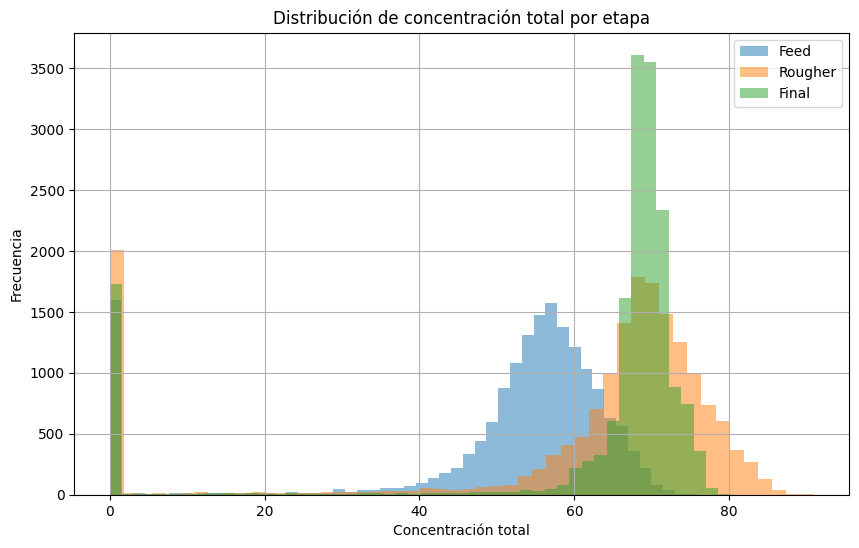

In [19]:
# Calcula la concentración total de sustancias por cada etapa del proceso
plt.figure(figsize=(10,6))

plt.hist(
    conc_tot_feed_analisis,
    bins=50,
    alpha=0.5,
    label='Feed'
)

plt.hist(
    conc_tot_r,
    bins=50,
    alpha=0.5,
    label='Rougher'
)

plt.hist(
    conc_tot_final,
    bins=50,
    alpha=0.5,
    label='Final'
)


plt.title('Distribución de concentración total por etapa')
plt.xlabel('Concentración total')
plt.ylabel('Frecuencia')

plt.legend()
plt.grid(True)

plt.show()

### Hallazgos
* Recordemos que en este momento estamos usando los datos completos y preprocesados del train (`df_train_analisis`)
    * se encontraron vaores anómalos de 0 en concentraciones totales por etapa; Esto quiere decir que hay filas que muestran que la cantidad de Au=0, Ag=0, Pb=0 y sol=0 al mismo tiempo. Esto puede deberse a dos cosas:
    * Paro de planta (mantenimiento, fallas, paradas programadad)
    * Fallo de sensores (por alguna razón los sensorer marcan cero pero la máquina sigue operando)

**Siguientes pasos**
* Verificar si los valores para concentraciones totales por etapa en 0 provienen del preprocesamiento o los datos originales
* Revisar los lapsos de tiempo durante los cuales los valores fueron 0

In [20]:
# Describe estadísticamente cada set de concentraciones totales por etapa tanto en train (solo en feed) cono en train_analisis
print(conc_tot_feed_analisis.describe())
print('='*30)
print(conc_tot_feed_train.describe())
print('='*30)
print(conc_tot_r.describe())
print('='*30)
print(conc_tot_final.describe())

count    16860.000000
mean        50.443496
std         18.176831
min          0.000000
25%         50.290705
50%         55.787615
75%         60.262953
max         76.024095
dtype: float64
count    16860.000000
mean        50.443496
std         18.176831
min          0.000000
25%         50.290705
50%         55.787615
75%         60.262953
max         76.024095
dtype: float64
count    16860.000000
mean        59.961791
std         24.042979
min          0.000000
25%         61.468859
50%         68.332115
75%         73.020072
max         90.964431
dtype: float64
count    16860.000000
mean        61.267542
std         21.690164
min          0.000000
25%         66.531283
50%         68.803475
75%         70.695552
max         80.210644
dtype: float64


In [21]:
# confirma igualdad entre datos originales y preprocesados
preprocesado = df_train_analisis[(df_train_analisis['rougher.input.feed_au']==0) &
    (df_train_analisis['rougher.input.feed_ag']==0) &
    (df_train_analisis['rougher.input.feed_pb']==0) &
    (df_train_analisis['rougher.input.feed_sol']==0)]

original= gr_train[(gr_train['rougher.input.feed_au']==0) &
    (gr_train['rougher.input.feed_ag']==0) &
    (gr_train['rougher.input.feed_pb']==0) &
    (gr_train['rougher.input.feed_sol']==0)]

print(f"¿Son iguales las concentraciones totales en el conjunto crudo de train y el preprocesado? {preprocesado.equals(original)}")

¿Son iguales las concentraciones totales en el conjunto crudo de train y el preprocesado? True


### Hallazgos
* Se confirma que los ceros en las concentraciones totales provienen de los datos de origen
**Próximos pasos**
* Se utilizará `.diff()` con `value_counts()` sobre el conjunto de entrenamiento y el conjunto de concentraciones totales = 0 del entrenamiento para compararlas

In [22]:
print(df_train['date'].diff().value_counts())
ceros_en_conc_feed= df_train[(df_train['rougher.input.feed_au']==0) &
    (df_train['rougher.input.feed_ag']==0) &
    (df_train['rougher.input.feed_pb']==0) &
    (df_train['rougher.input.feed_sol']==0)]
print(ceros_en_conc_feed['date'].diff().value_counts())

0 days 01:00:00      16856
122 days 01:00:00        2
0 days 00:00:00          1
Name: date, dtype: int64
0 days 01:00:00      1157
0 days 04:00:00         3
0 days 05:00:00         3
3 days 22:00:00         2
0 days 20:00:00         1
6 days 02:00:00         1
18 days 07:00:00        1
21 days 14:00:00        1
19 days 23:00:00        1
2 days 07:00:00         1
4 days 21:00:00         1
23 days 00:00:00        1
19 days 20:00:00        1
4 days 05:00:00         1
13 days 18:00:00        1
4 days 22:00:00         1
9 days 11:00:00         1
15 days 01:00:00        1
18 days 12:00:00        1
129 days 05:00:00       1
0 days 03:00:00         1
0 days 10:00:00         1
0 days 06:00:00         1
3 days 05:00:00         1
0 days 16:00:00         1
8 days 04:00:00         1
14 days 09:00:00        1
139 days 10:00:00       1
6 days 22:00:00         1
6 days 10:00:00         1
0 days 07:00:00         1
13 days 07:00:00        1
1 days 17:00:00         1
16 days 15:00:00        1
6 days 19:

### Hallazgos
* Existen 1157 mediciones seguidas (una por hora) en las que la concentración total fue siempre 0
* Las 55 restanntes corresponden a saltos que parecen coincidir con fallos de operación o reinicio de la máquina

**Siguientes pasos**
* Se creará una máscara booleana a partir de de un objeto `Timedelda` 

In [23]:
print(len(ceros_en_conc_feed))
print(len(df_train['date']))

1213
16860


In [24]:
# Crea una máscara para identificar las filas con diferencia de 1 hora entre fechas consecutivas añadiendo la primera fila del diff
diff_1_hr = ceros_en_conc_feed['date'].diff().fillna(pd.Timedelta(hours=1))
mask_1hr= diff_1_hr == pd.Timedelta(hours=1)
# se filtran los datos a eliminar y a rellenar con NaN según la máscara creada
para_eliminar= ceros_en_conc_feed[mask_1hr]
para_rellenar= ceros_en_conc_feed[~mask_1hr]
# Cambia valores de filas a nan para rellenar con ffill
df_train.loc[para_rellenar.index] = np.nan
df_train.fillna(method='ffill', inplace=True)
# Elimina las filas de para_eliminar 
df_train.drop(para_eliminar.index, inplace=True)
df_train_clean= df_train.drop('date', axis=1)
df_test_clean= df_test.drop('date', axis=1)

In [25]:
#Comprueba que no queden mas valores de cero en concentración total
print(len(df_train_clean[(df_train_clean['rougher.input.feed_au']==0) &
    (df_train_clean['rougher.input.feed_ag']==0) &
    (df_train_clean['rougher.input.feed_pb']==0) &
    (df_train_clean['rougher.input.feed_sol']==0)]))

0


### Conclusión:
* Se encontraron datos anómalos para las concentraciones totales
    * Se analizó y se dividieron en dos grupos
        * paro de producción: se eliminaron dichos valores (1157)
        * errores asociados a sensores o reinicios: se rellenaron con el inmediato anterior (55)
    * Se comprobó que no quedaran más datos anómalos
el conjunto de entrenamiento está listo para el modelo

# 3. Construcción del modelo

## 3.1 Cálculo de sMAPE

In [26]:
def sMAPE(y_true, y_pred):
    """
    Calcula el error porcentual absoluto medio simétrico (sMAPE) entre los valores reales y predichos.

    Parámetros:
    y_true : array-like
        Valores reales.
    y_pred : array-like
        Valores predichos.

    Retorna:
    float
        El valor de sMAPE.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    #restringe valores cuando el denominador es cero (y_true=y_pred_0) para evitar división por cero
    

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator[denominator == 0] = np.nan
    diff = np.abs(y_true - y_pred) / denominator
    return np.nanmean(diff)* 100
def sMAPE_final(r_smape, fin_smape):
    res = 0.25*(r_smape) + .75*(fin_smape)
    return res

### Conclusiones 
Se han creado las funciones para calcular los smape por separado y el smape final


## 3.2 entrenamiento de modelos
* Se entrenarán tres tipos de modelo evaluándolos con validación cruzada

* Se elegira el mejor modelo


### Modelo Dummy de regresion lineal

In [ ]:
features = df_train_clean.drop(
    ['rougher.output.recovery', 'final.output.recovery'],
    axis=1
)

targets = df_train_clean[
    ['rougher.output.recovery', 'final.output.recovery']
]


model_lr = LinearRegression()
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=54321
)
smape_scores_lr = []
for train_index, valid_index in kf.split(features):
    train_features = features.iloc[train_index]
    valid_features = features.iloc[valid_index]
    train_target = targets.iloc[train_index]
    valid_target = targets.iloc[valid_index]
    # Se entrena el modelo de regresión lineal con los datos de entrenamiento
    model_lr.fit(
        train_features,
        train_target
    )
    # genera las predicciones para el conjunto de validación
    predictions = pd.DataFrame(
        model_lr.predict(valid_features),
        columns=targets.columns
    )
    # calcula el sMAPE para rougher y final
    smape_r = sMAPE(
        valid_target['rougher.output.recovery'],
        predictions['rougher.output.recovery']
    )
    # calcula el sMAPE final
    smape_f = sMAPE(
        valid_target['final.output.recovery'],
        predictions['final.output.recovery']
    )

    smape_scores_lr.append(
        sMAPE_final(smape_r, smape_f)
    )
print(
    f"Regresión lineal sMAPE promedio: {np.mean(smape_scores_lr):.2f}"
)

Regresión lineal sMAPE promedio: 11.55


In [ ]:
model = LinearRegression()
smape_final= []
kf= KFold(n_splits=5, shuffle=True, random_state=54321)
for train_index, valid_index in kf.split(features):
    train_features, valid_features = features.iloc[train_index], features.iloc[valid_index]
    train_target, valid_target = targets.iloc[train_index], targets.iloc[valid_index]
    model.fit(train_features, train_target)
    predictions = pd.DataFrame(model.predict(valid_features), columns=targets.columns)
    smape_r= sMAPE(valid_target['rougher.output.recovery'], predictions['rougher.output.recovery'])
    smape_f= sMAPE(valid_target['final.output.recovery'], predictions['final.output.recovery'])
    smape_final.append(sMAPE_final(smape_r, smape_f))
rendimiento = np.mean(smape_final)
print(f"El rendimiento del modelo de regresión lineal es: {rendimiento:.2f}")

El rendimiento del modelo de regresión lineal es: 11.55


### Modelo random forest regresor


In [ ]:
features= df_train
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=54321
)
smape_scores_rf = []
for train_index, valid_index in kf.split(features):

    train_features = features.iloc[train_index]
    valid_features = features.iloc[valid_index]
    train_target = targets.iloc[train_index]
    valid_target = targets.iloc[valid_index]


    model_rf.fit(
        train_features,
        train_target
    )


    predictions = pd.DataFrame(
        model_rf.predict(valid_features),
        columns=targets.columns
    )


    smape_r = sMAPE(
        valid_target['rougher.output.recovery'],
        predictions['rougher.output.recovery']
    )


    smape_f = sMAPE(
        valid_target['final.output.recovery'],
        predictions['final.output.recovery']
    )


    smape_scores_rf.append(
        sMAPE_final(smape_r, smape_f)
    )


print(
    f"Random Forest sMAPE promedio: {np.mean(smape_scores_rf):.2f}"
)

Random Forest sMAPE promedio: 8.18


In [31]:
features= df_train_clean.drop(['rougher.output.recovery', 'final.output.recovery'], axis=1)
targets= df_train_clean[['rougher.output.recovery', 'final.output.recovery']]
model_2 = RandomForestRegressor(n_estimators=100, random_state=54321)
kf= KFold(n_splits=5, shuffle=True, random_state=54321)
smape_final = []
for train_index, valid_index in kf.split(features):
    train_features, valid_features = features.iloc[train_index], features.iloc[valid_index]
    train_target, valid_target = targets.iloc[train_index], targets.iloc[valid_index]
    model_2.fit(train_features, train_target)
    predictions = pd.DataFrame(model_2.predict(valid_features), columns=targets.columns)
    smape_r= sMAPE(valid_target['rougher.output.recovery'], predictions['rougher.output.recovery'])
    smape_f= sMAPE(valid_target['final.output.recovery'], predictions['final.output.recovery'])
    smape_final.append(sMAPE_final(smape_r, smape_f))
rendimiento = np.mean(smape_final)
print(f"El rendimiento del modelo de random forest es: {rendimiento:.2f}")

El rendimiento del modelo de random forest es: 8.18


In [ ]:
# Obtener del dataset gr_full los targets los que corresponderían a lconj
# unto test
model_2 = RandomForestRegressor(n_estimators=100, random_state=54321)
model_2.fit(train_features, train_target)
predictions_test = pd.DataFrame(model_2.predict(df_test_clean), columns=df_test_targets.columns)
gr_full['date'] = pd.to_datetime(gr_full['date']).dt.floor('H')
df_test_targets= gr_full.loc[gr_full['date'].isin(gr_test['date']), ['rougher.output.recovery', 'final.output.recovery']]
smape_r_test= sMAPE(df_test_targets['rougher.output.recovery'], predictions_test['rougher.output.recovery'])
smape_f_test= sMAPE(df_test_targets['final.output.recovery'], predictions_test['final.output.recovery'])
smape_final_test= sMAPE_final(smape_r_test, smape_f_test)
print(f"El rendimiento del modelo de random forest en el conjunto test es: {smape_final_test:.2f}")

El rendimiento del modelo de random forest en el conjunto test es: 11.28


## Modelo gradient boosting


In [ ]:
model_gb = MultiOutputRegressor(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=54321
    )
)


smape_scores_gb = []


for train_index, valid_index in kf.split(features):

    train_features = features.iloc[train_index]
    valid_features = features.iloc[valid_index]

    train_target = targets.iloc[train_index]
    valid_target = targets.iloc[valid_index]


    model_gb.fit(
        train_features,
        train_target
    )


    predictions = pd.DataFrame(
        model_gb.predict(valid_features),
        columns=targets.columns
    )


    smape_r = sMAPE(
        valid_target['rougher.output.recovery'],
        predictions['rougher.output.recovery']
    )


    smape_f = sMAPE(
        valid_target['final.output.recovery'],
        predictions['final.output.recovery']
    )


    smape_scores_gb.append(
        sMAPE_final(smape_r, smape_f)
    )


print(
    f"Gradient Boosting sMAPE promedio: {np.mean(smape_scores_gb):.2f}"
)

## comparación de modelos

In [ ]:
resultados = pd.DataFrame({
    'Modelo': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'sMAPE': [
        np.mean(smape_scores_lr),
        np.mean(smape_scores_rf),
        np.mean(smape_scores_gb)
    ]
})


resultados.sort_values(
    'sMAPE'
)

# Entrenamiento del mejor modelo

In [ ]:
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=54321
)


best_model.fit(
    features,
    targets
)

# Prueba final del modelo

In [ ]:
gr_full['date'] = pd.to_datetime(gr_full['date']).dt.floor('H')
df_test_targets= gr_full.loc[gr_full['date'].isin(gr_test['date']), ['rougher.output.recovery', 'final.output.recovery']]
predictions_test = pd.DataFrame(best_model.predict(df_test_clean), columns=df_test_targets.columns)


smape_r_test = sMAPE(
    df_test_targets['rougher.output.recovery'],
    predictions_test['rougher.output.recovery']
)


smape_f_test = sMAPE(
    df_test_targets['final.output.recovery'],
    predictions_test['final.output.recovery']
)


smape_final_test = sMAPE_final(
    smape_r_test,
    smape_f_test
)


print(
    f"sMAPE final en test: {smape_final_test:.2f}"
)